In [200]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [201]:
url = 'https://raw.githubusercontent.com/samiralikperov/ml-portfolio/main/Zoomcamp/03-classification/bank-full.csv'
df = pd.read_csv(url, sep=";")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [202]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [203]:
df.isna().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


We need to take bank/bank-full.csv file from the downloaded zip-file.
In this dataset our desired target for classification task will be y variable - has the client subscribed a term deposit or not.

## Features.
For the rest of the homework, you'll need to use only these columns:

age,  
job,  
marital,  
education,  
balance,  
housing,  
contact,  
day,  
month,  
duration,  
campaign,  
pdays,  
previous,  
poutcome,  
y  

## Data preparation
Select only the features from above.  
Check if the missing values are presented in the features.


In [204]:
# Subset the dataset.
selected_columns = ['age', 'job', 'marital', 'education', 'balance', 'housing', 'contact', 'day',
             'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

df = df[selected_columns]
df

,age,job,marital,education,balance,housing,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,2143,yes,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,29,yes,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,2,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,1506,yes,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,1,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,825,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,1729,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,5715,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,668,no,telephone,17,nov,508,4,-1,0,unknown,no


In [205]:
df.isna().sum()

,0
age,0
job,0
marital,0
education,0
balance,0
housing,0
contact,0
day,0
month,0
duration,0


In [206]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


## Question 1.
What is the most frequent observation (mode) for the column education?  

-  unknown
-  primary
-  secondary
-  tertiary

In [207]:
df.education.mode()

,education
0,secondary


In [208]:
#check mode
df["education"].value_counts()

,count
education,
secondary,23202
tertiary,13301
primary,6851
unknown,1857


## Question 2.
Create the correlation matrix for the numerical features of your dataset. In a correlation matrix, you compute the correlation coefficient between every pair of features.  

What are the two features that have the biggest correlation?  

-  age and balance
-  day and campaign
-  day and pdays
-  pdays and previous

### Target encoding
-  Now we want to encode the y variable.
-  Let's replace the values yes/no with 1/0.  

### Split the data
-  Split your data in train/val/test sets with 60%/20%/20% distribution.
-  Use Scikit-Learn for that (the train_test_split function) and set the seed to 42.
-  Make sure that the target value y is not in your dataframe.

In [209]:
df_number = df.copy().select_dtypes(include='number')
df_number

,age,balance,day,duration,campaign,pdays,previous
0,58,2143,5,261,1,-1,0
1,44,29,5,151,1,-1,0
2,33,2,5,76,1,-1,0
3,47,1506,5,92,1,-1,0
4,33,1,5,198,1,-1,0
...,...,...,...,...,...,...,...
45206,51,825,17,977,3,-1,0
45207,71,1729,17,456,2,-1,0
45208,72,5715,17,1127,5,184,3
45209,57,668,17,508,4,-1,0


In [210]:
df_number.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [211]:
corr_matrix  = df_number.corr()
corr_matrix

,age,balance,day,duration,campaign,pdays,previous
age,1.000000,0.097783,-0.009120,-0.004648,0.004760,-0.023758,0.001288
balance,0.097783,1.000000,0.004503,0.021560,-0.014578,0.003435,0.016674
day,-0.009120,0.004503,1.000000,-0.030206,0.162490,-0.093044,-0.051710
duration,-0.004648,0.021560,-0.030206,1.000000,-0.084570,-0.001565,0.001203
campaign,0.004760,-0.014578,0.162490,-0.084570,1.000000,-0.088628,-0.032855
pdays,-0.023758,0.003435,-0.093044,-0.001565,-0.088628,1.000000,0.454820
previous,0.001288,0.016674,-0.051710,0.001203,-0.032855,0.454820,1.000000


In [212]:
corr_matrix_un = df_number.corr().unstack().sort_values(ascending = False)
corr_matrix_un

age       age         1.000000
balance   balance     1.000000
pdays     pdays       1.000000
campaign  campaign    1.000000
day       day         1.000000
duration  duration    1.000000
previous  previous    1.000000
          pdays       0.454820
pdays     previous    0.454820
campaign  day         0.162490
day       campaign    0.162490
age       balance     0.097783
balance   age         0.097783
          duration    0.021560
duration  balance     0.021560
balance   previous    0.016674
previous  balance     0.016674
age       campaign    0.004760
campaign  age         0.004760
balance   day         0.004503
day       balance     0.004503
balance   pdays       0.003435
pdays     balance     0.003435
previous  age         0.001288
age       previous    0.001288
duration  previous    0.001203
previous  duration    0.001203
pdays     duration   -0.001565
duration  pdays      -0.001565
age       duration   -0.004648
duration  age        -0.004648
age       day        -0.009120
day       age        -0.009120
balance   campaign   -0.014578
campaign  balance    -0.014578
pdays     age        -0.023758
age       pdays      -0.023758
duration  day        -0.030206
day       duration   -0.030206
previous  campaign   -0.032855
campaign  previous   -0.032855
day       previous   -0.051710
previous  day        -0.051710
duration  campaign   -0.084570
campaign  duration   -0.084570
pdays     campaign   -0.088628
campaign  pdays      -0.088628
day       pdays      -0.093044
pdays     day        -0.093044
dtype: float64

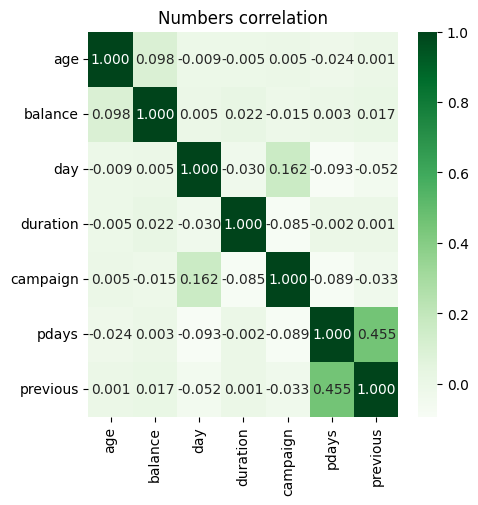

In [213]:
#visual
plt.figure(figsize=(5,5))
sns.heatmap(df_number.corr(), cmap="Greens", annot=True, fmt='.3f')
plt.title('Numbers correlation')
plt.show()

In [214]:
#check
corr_matrix.unstack().abs()[corr_matrix.unstack().abs().lt(1)].idxmax()

('pdays', 'previous')

In [215]:
# Target encoding
# -  Now we want to encode the y variable.
# -  Let's replace the values yes/no with 1/0.

df.y = (df.y == 'yes').astype(int)
df.tail()

,age,job,marital,education,balance,housing,contact,day,month,duration,campaign,pdays,previous,poutcome,y
45206,51,technician,married,tertiary,825,no,cellular,17,nov,977,3,-1,0,unknown,1
45207,71,retired,divorced,primary,1729,no,cellular,17,nov,456,2,-1,0,unknown,1
45208,72,retired,married,secondary,5715,no,cellular,17,nov,1127,5,184,3,success,1
45209,57,blue-collar,married,secondary,668,no,telephone,17,nov,508,4,-1,0,unknown,0
45210,37,entrepreneur,married,secondary,2971,no,cellular,17,nov,361,2,188,11,other,0


In [216]:
df.y

,y
0,0
1,0
2,0
3,0
4,0
...,...
45206,1
45207,1
45208,1
45209,0


In [217]:
df.y.value_counts(normalize=True)

,proportion
y,
0,0.883015
1,0.116985


In [218]:
### Split the data
# -  Split your data in train/val/test sets with 60%/20%/20% distribution.
# -  Use Scikit-Learn for that (the train_test_split function) and set the seed to 42.
# -  Make sure that the target value y is not in your dataframe.

from sklearn.model_selection import train_test_split

In [219]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=42)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=42)
len(df_train), len(df_val), len(df_test)

(27126, 9042, 9043)

In [220]:
# reset index
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [221]:
y_train = df_train.y.values
y_val = df_val.y.values
y_test = df_test.y.values

del df_train['y']
del df_val['y']
del df_test['y']

## Question 3.
Calculate the mutual information score between y and other categorical variables in the dataset. Use the training set only.
Round the scores to 2 decimals using round(score, 2).

Which of these variables has the biggest mutual information score?  

-  contact
-  education
-  housing
-  poutcome

In [222]:
#import mutual_info_score
from sklearn.metrics import mutual_info_score

In [223]:
df_categorical = df.copy().select_dtypes(exclude='number').columns
df_categorical

Index(['job', 'marital', 'education', 'housing', 'contact', 'month',
       'poutcome'],
      dtype='object')

In [224]:
categorical = ['job', 'marital', 'education', 'housing', 'contact', 'month','poutcome']

In [225]:
mi = df_train[categorical].apply(lambda s: mutual_info_score(s, y_train))
mi.sort_values(ascending=False)

,0
poutcome,0.029533
month,0.025090
contact,0.013356
housing,0.010343
job,0.007316
education,0.002697
marital,0.002050


## Question 4.
Now let's train a logistic regression.  
Remember that we have several categorical variables in the dataset. Include them using one-hot encoding.  
Fit the model on the training dataset.  
-    To make sure the results are reproducible across different versions of Scikit-Learn, fit the model with these parameters:
-    model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
Calculate the accuracy on the validation dataset and round it to 2 decimal digits.

What accuracy did you get?  

-  0.6
-  0.7
-  0.8
-  0.9

In [226]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [227]:
# X_train,y_train to model
dv = DictVectorizer(sparse=False)
train_dict = df_train.to_dict(orient='records')
X_train = dv.fit_transform(train_dict)
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')

In [228]:
val_dict = df_val.to_dict(orient='records')
X_val = dv.transform(val_dict)
y_pred = model.predict(X_val)
accuracy = accuracy_score(y_val, y_pred)
accuracy

0.9009068790090687

## Question 5  

- Let's find the least useful feature using the feature elimination technique.
- Train a model with all these features (using the same parameters as in Q4).
- Now exclude each feature from this set and train a model without it. Record the accuracy for each model.
- For each feature, calculate the difference between the original accuracy and the accuracy without the feature.


Which of following feature has the smallest difference?

- age
- balance
- marital
- previous

In [229]:

features = df_train.columns.tolist()
scores = []

for feature in features:
    subset = [f for f in features if f != feature]

    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(df_train[subset].to_dict(orient='records'))

    # Train the logistic regression
    model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
    model.fit(X_train, y_train)

    # Convert the validation data and predict the results
    X_val = dv.transform(df_val[subset].to_dict(orient='records'))
    score = accuracy_score(y_val, model.predict(X_val))

    # Add the feature and its accuracy score
    scores.append({'eliminated_feature': feature, 'accuracy': score, 'difference': abs(accuracy - score)})

# Convert the list to a DataFrame
scores_df = pd.DataFrame(scores)

print(scores_df)

least_useful_feature = scores_df.loc[scores_df['difference'].idxmin()]
print(f"Least useful feature:\n{least_useful_feature}")


   eliminated_feature  accuracy  difference
0                 age  0.901349    0.000442
1                 job  0.901128    0.000221
2             marital  0.900907    0.000000
3           education  0.900907    0.000000
4             balance  0.901017    0.000111
5             housing  0.901128    0.000221
6             contact  0.900464    0.000442
7                 day  0.901349    0.000442
8               month  0.899801    0.001106
9            duration  0.889737    0.011170
10           campaign  0.900243    0.000664
11              pdays  0.900907    0.000000
12           previous  0.900907    0.000000
13           poutcome  0.893386    0.007520
Least useful feature:
eliminated_feature     marital
accuracy              0.900907
difference                 0.0
Name: 2, dtype: object


## Question 6
- Now let's train a regularized logistic regression.
- Let's try the following values of the parameter C: [0.01, 0.1, 1, 10, 100].
- Train models using all the features as in Q4.
- Calculate the accuracy on the validation dataset and round it to 3 decimal digits.


Which of these C leads to the best accuracy on the validation set?

- 0.01
- 0.1
- 1
- 10
- 100

In [230]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=42)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=42)

assert len(df) == (len(df_train) + len(df_val) + len(df_test))

# Reset index for train, validation, and test sets
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

# Define target variables for train, validation, and test sets
y_train = df_train['y'].values
y_val = df_val['y'].values
y_test = df_test['y'].values

# Drop the target column from the feature sets
df_train = df_train.drop(columns='y')
df_val = df_val.drop(columns='y')
df_test = df_test.drop(columns='y')

#check
y_train.shape, y_val.shape


((27126,), (9042,))

In [231]:
dv = DictVectorizer(sparse=False)

X_train = dv.fit_transform(df_train.to_dict(orient='records'))
X_val = dv.transform(df_val.to_dict(orient='records'))

# Train the model with different values of C and store the results
scores = {}
for C in [0.01, 0.1, 1, 10, 100]:
    model = LogisticRegression(solver='liblinear', C=C, max_iter=1000, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    accuracy = accuracy_score(y_val, y_pred)

    scores[C] = round(accuracy, 3)
    print(f'C = {C}:\tAccuracy = {accuracy:.3f}')


C = 0.01:	Accuracy = 0.898
C = 0.1:	Accuracy = 0.901
C = 1:	Accuracy = 0.901
C = 10:	Accuracy = 0.901
C = 100:	Accuracy = 0.901


In [232]:
print(scores)

{0.01: 0.898, 0.1: 0.901, 1: 0.901, 10: 0.901, 100: 0.901}


In [233]:
best_C = max(scores, key=scores.get)
print(f'The smallest C with the best accuracy is {best_C}.')

The smallest C with the best accuracy is 0.1.
